In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [2]:
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
# 2. Dataset Path

dataset_path = "../PlantVillage"

classes = [
    "Pepper_bell_Bacterial_spot",
    "Pepper_bell_healthy"
]


BATCH_SIZE = 32
IMG_HEIGHT = 128
IMG_WIDTH = 128

dataset = image_dataset_from_directory(
  dataset_path,
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

# getting classes names using class_names

class_names = dataset.class_names
print("classes:", class_names)



Found 2475 files belonging to 2 classes.
classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


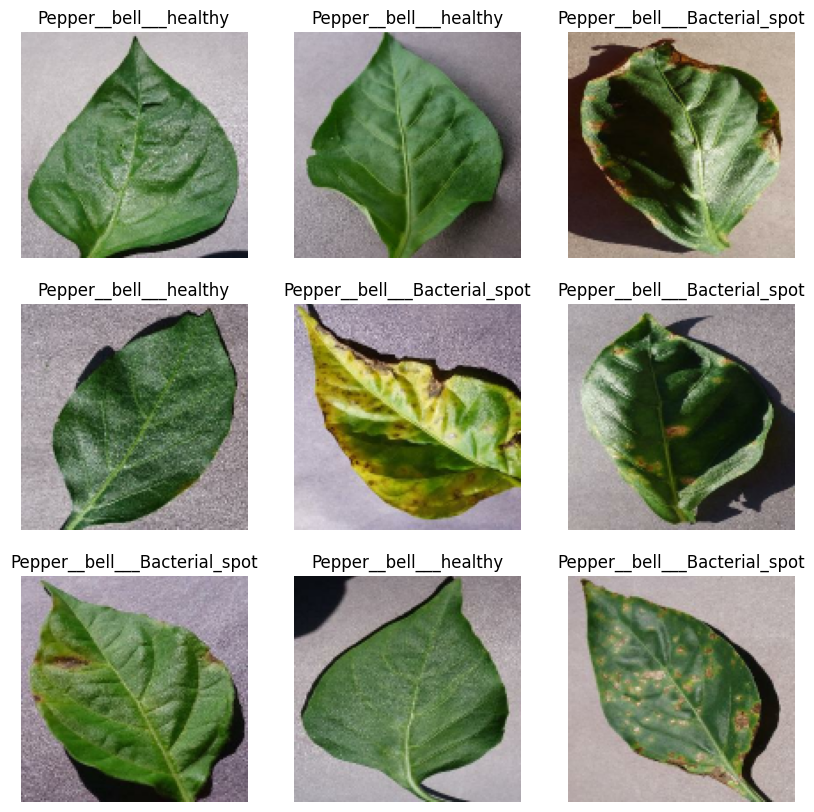

In [4]:
# ==========================================
# 3. Visualize Sample Images
# ==========================================

plt.figure(figsize=(10, 10))

for images, labels in dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [5]:
# ==========================================
# 4. Dataset Information
# ==========================================

print("Class Names :", class_names)

print("Number of Classes :", len(class_names))

for image_batch, labels_batch in dataset.take(1):

    print("Image Batch Shape :", image_batch.shape)

    print("Label Batch Shape :", labels_batch.shape)

Class Names : ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']
Number of Classes : 2
Image Batch Shape : (32, 128, 128, 3)
Label Batch Shape : (32,)


In [6]:
# ==========================================
# 5. Split Dataset into Train and Validation
# ==========================================

dataset_size = len(dataset)

train_size = int(0.8 * dataset_size)

train_dataset = dataset.take(train_size)

val_dataset = dataset.skip(train_size)

print("Total Batches :", dataset_size)

print("Training Batches :", len(train_dataset))

print("Validation Batches :", len(val_dataset))

Total Batches : 78
Training Batches : 62
Validation Batches : 16


In [7]:
# ==========================================
# 6. Optimize Dataset Performance
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
# ==========================================
# 7. Normalize Images
# ==========================================

normalization_layer = tf.keras.layers.Rescaling(1./255)

normalized_train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

normalized_val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [9]:
# ==========================================
# 8. Check Normalized Images
# ==========================================

for image_batch, labels_batch in normalized_train_dataset.take(1):

    first_image = image_batch[0]

    print("Minimum Pixel Value :", np.min(first_image))

    print("Maximum Pixel Value :", np.max(first_image))

Minimum Pixel Value : 0.0
Maximum Pixel Value : 0.9029412


In [10]:
# ==========================================
# 9. Data Augmentation
# ==========================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

])

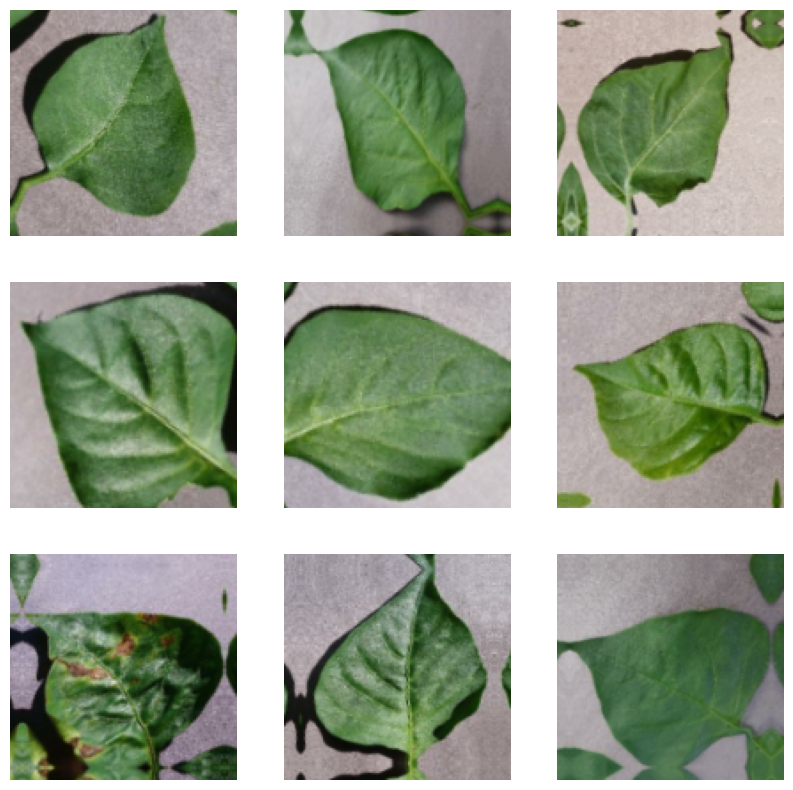

In [11]:
# ==========================================
# 10. Visualize Augmented Images
# ==========================================

plt.figure(figsize=(10, 10))

for images, _ in normalized_train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_images[i].numpy())

        plt.axis("off")

plt.show()

In [12]:
# ==========================================
# 11. Save Processed Dataset (Optional)
# ==========================================

train_dataset.save("processed_train_dataset")

val_dataset.save("processed_validation_dataset")

print("Datasets saved successfully.")

Datasets saved successfully.


In [13]:
# ==========================================
# 12. Final Ready Message
# ==========================================

print("Data preprocessing completed successfully.")

print("Dataset is ready for CNN model training.")

Data preprocessing completed successfully.
Dataset is ready for CNN model training.
